In [1]:
from aoespy import *

/home6/afahad/.local/lib/python3.9/site-packages/aoespy.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
import xarray as xr
import ecco_v4_py as ecco
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from glob import glob
import os


#

In [4]:
def readmit(exp='GEOSMIT35_ctrl',loc='/nobackupp27/afahad/exp/',file='state_3d_set1',var=1,start_date='20050501',nfiles=120,freq='D',nz=50, nf=6, ni=90, nj=90, ntile=13,expdir='../mit_output/'):
    
    input_dir = '/nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02'
    input_file = 'bathy_eccollc_90x50_min2pts.bin'
    os.chdir(loc+exp+'/plot')
    pdir='../plots_CLIM/ocean_mit/'
    vdir='/nobackupp27/afahad/mit_diag/'
    try:
        os.system('mkdir -p '+pdir)
    except:
        None

    bathy = ecco.read_llc_to_tiles(input_dir, input_file)

    ecco_grid = ecco.load_ecco_grid_nc(input_dir, 'ECCO-GRID.nc')


    
    restarts='../restarts/'

    os.chdir(expdir)
    files=np.array(sorted(glob(file+'*.data'))[0:nfiles])
    time=pd.date_range(start_date,periods=len(files),freq=freq)
    
    djf_files=files

    nt=len(time); 

    ndjf=len(djf_files)

    theta_djf=np.zeros((ndjf,nz,ntile,nj,ni)); theta_djf[:]=np.nan
    
    print('reading files')
    for i in range(ndjf):
        print(djf_files[i])
        data=ecco.read_llc_to_tiles(expdir, djf_files[i], nk=-1,nl=-1)
        print(data.shape)
        data=np.reshape(data, (nf,nz,ntile,nj,ni))
        theta_djf[i,:,:,:]=data[var,:,:,:,:]
    return (theta_djf, time)
    
def llc2grd(theta_djf,nz=50):
    input_dir = '/nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02'
    input_file = 'bathy_eccollc_90x50_min2pts.bin'
    ecco_grid = ecco.load_ecco_grid_nc(input_dir, 'ECCO-GRID.nc')
    theta_djf_all=np.zeros(theta_djf.shape)
    theta_djf_all[:]=theta_djf

    new_grid_delta_lat = 1
    new_grid_delta_lon = 1

    new_grid_min_lat = -90
    new_grid_max_lat = 91

    new_grid_min_lon = -180
    new_grid_max_lon = 180

    new_lat=np.arange(-90,91,1); nlat=len(new_lat)
    new_lon=np.arange(-180,180,1); nlon=len(new_lon)

    tt=len(theta_djf)
    theta_djf_alli=np.zeros((tt,nz,nlat,nlon))

    for i in range(tt):
        for j in range(nz):

            new_grid_lon_centers, new_grid_lat_centers,\
            new_grid_lon_edges, new_grid_lat_edges,\
            theta_djf_alli[i,j,:,:] =\
                    ecco.resample_to_latlon(ecco_grid.XC, \
                                            ecco_grid.YC, \
                                            theta_djf_all[i,j,:,:,:],\
                                            new_grid_min_lat, new_grid_max_lat, new_grid_delta_lat,\
                                            new_grid_min_lon, new_grid_max_lon, new_grid_delta_lon,\
                                            fill_value = np.NaN, \
                                            mapping_method = 'nearest_neighbor',
                                            radius_of_influence = 120000)
    return (np.squeeze(theta_djf_alli), new_lon, new_lat)


In [58]:

ME506, time=readmit('GEOSMIT_ME0506',file='state_2d_set1',var=10,nz=1,nfiles=64,nf=11,freq='1D',start_date='20050506', )
ME506=ME506[:,0:1,:,:,:]
ME506,lon,lat=llc2grd(ME506,nz=1)

RP506, time=readmit('GEOSMIT_RP0506',file='state_2d_set1',var=10,nz=1,nfiles=64,nf=11,freq='1D',start_date='20050506', )
RP506=RP506[:,0:1,:,:,:]
RP506,lon,lat=llc2grd(RP506,nz=1)

load_binary_array: loading file /nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02/bathy_eccollc_90x50_min2pts.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
reading files
state_2d_set1.0000000060.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000000060.data
load_binary_array: loading all 2D records.  nk = 11
load_binary_array: data array shape  (11, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (11, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (11, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(11, 13, 90, 90)
state_2d_set1.0000000252.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000000252.data
load_binary_arra

llc_faces_to_tiles: data_tiles shape  (11, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(11, 13, 90, 90)
state_2d_set1.0000008316.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000008316.data
load_binary_array: loading all 2D records.  nk = 11
load_binary_array: data array shape  (11, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (11, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (11, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(11, 13, 90, 90)
state_2d_set1.0000008508.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000008508.data
load_binary_array: loading all 2D records.  nk = 11
load_binary_array: data array shape  (11, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (11, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (11, 13, 90, 90)
llc_faces_to_

load_binary_array: loading file /nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02/bathy_eccollc_90x50_min2pts.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
reading files
state_2d_set1.0000015996.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000015996.data
load_binary_array: loading all 2D records.  nk = 11
load_binary_array: data array shape  (11, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (11, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (11, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(11, 13, 90, 90)
state_2d_set1.0000016188.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000016188.data
load_binary_arra

llc_faces_to_tiles: data_tiles shape  (11, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(11, 13, 90, 90)
state_2d_set1.0000023484.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000023484.data
load_binary_array: loading all 2D records.  nk = 11
load_binary_array: data array shape  (11, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (11, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (11, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
(11, 13, 90, 90)
state_2d_set1.0000023676.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000023676.data
load_binary_array: loading all 2D records.  nk = 11
load_binary_array: data array shape  (11, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (11, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (11, 13, 90, 90)
llc_faces_to_

In [59]:
ds = xr.Dataset(
    {
        "ME506": (["time", "lat", "lon"], ME506),
        "RP506": (["time", "lat", "lon"], RP506)
    },
    coords={
        "time": time,
        "lat": lat,
        "lon": lon
    }
)


ME506=ds.ME506.sel(time=slice('2005-05-06','2005-07-02'))
RP506=ds.RP506.sel(time=slice('2005-05-06','2005-07-02'))



In [60]:
ME506=ME506+273.16
RP506=RP506+273.16

ME506[0,:,:]=ME506[0,:,:]+1

In [8]:
RP506a=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4')
ME506a=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0506/holding/geosgcm_surf/200505/*surf*200505*z.nc4')

In [9]:
RP5062=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0506/holding/geosgcm_surf/200506/*surf*200506*z.nc4')
RP5063=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0506/holding/geosgcm_surf/200507/*surf*200507*z.nc4')


In [10]:
ME5062=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0506/holding/geosgcm_surf/200506/*surf*200506*z.nc4')
ME5063=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0506/holding/geosgcm_surf/200507/*surf*200507*z.nc4')


In [11]:
RP506a=xr.concat([RP506a,RP5062,RP5063],dim='time')
ME506a=xr.concat([ME506a,ME5062,ME5063],dim='time')


In [46]:
# RP506a=RP506a[['TS','TA']].sel(time=slice('2005-05-06','2005-07-02')).compute()
# ME506a=ME506a[['TS','TA']].sel(time=slice('2005-05-06','2005-07-02')).compute()

In [13]:
RP506a=RP506a.TA
ME506a=ME506a.TA

In [14]:
RP506a=RP506a.resample(time='1D').mean()
ME506a=ME506a.resample(time='1D').mean()

In [61]:
RP506=RP506.interp(lon=RP506a.lon,lat=RP506a.lat)
ME506=ME506.interp(lon=ME506a.lon,lat=ME506a.lat)

In [62]:
RP506=RP506-RP506a
ME506=ME506-ME506a

In [43]:
d=8
ME506=ME506a[d:]-ME506a.data[:-d]
RP506=RP506a[d:]-RP506a.data[:-d]

In [63]:
ticks=[]

for i in range(len(ME506.time)):
    ticks=append(ticks,str(ME506.time.data[i])[5:10])

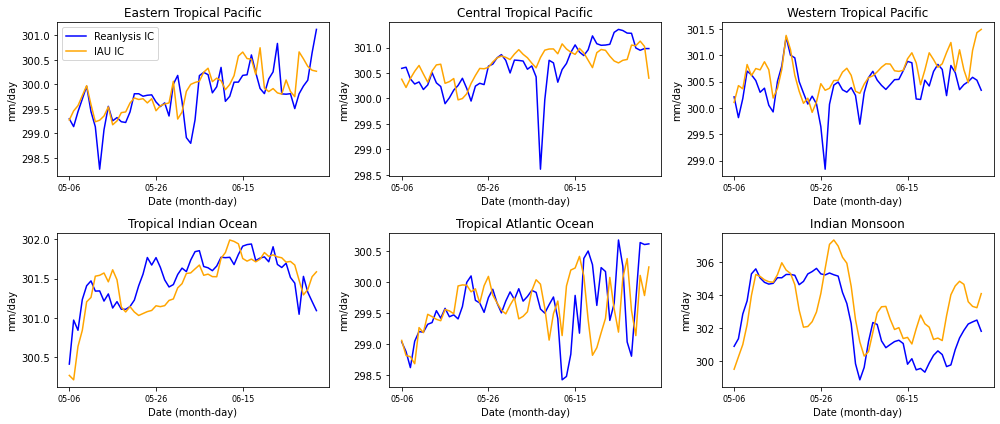

In [56]:

x1=-127
x2=-127
y1=7
y2=7

# x1=-116
# x2=-115
# y1=5
# y2=5

plt.figure(figsize=(14,6))
plt.subplot(2,3,1)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506a).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506a).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Eastern Tropical Pacific')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')


x1=-178
x2=-178
y1=2
y2=2

plt.subplot(2,3,2)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506a).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506a).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Central Tropical Pacific')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

# x1=136
# x2=137
# y1=3
# y2=4

x1=143
x2=143
y1=-1
y2=-1

plt.subplot(2,3,3)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506a).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506a).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Western Tropical Pacific')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=89
x2=92
y1=7
y2=8



plt.subplot(2,3,4)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506a).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506a).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Indian Ocean')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=-39
x2=-38
y1=7
y2=8



plt.subplot(2,3,5)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506a).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506a).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=90
x2=91
y1=23
y2=25

plt.subplot(2,3,6)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506a).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506a).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Indian Monsoon')
plt.xticks(arange(len(ticks))[::20],ticks[::20],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('mm/day')

x1=32
x2=35
y1=-1
y2=2



plt.tight_layout()
#plt.savefig('spike_pr.png',dpi=150)

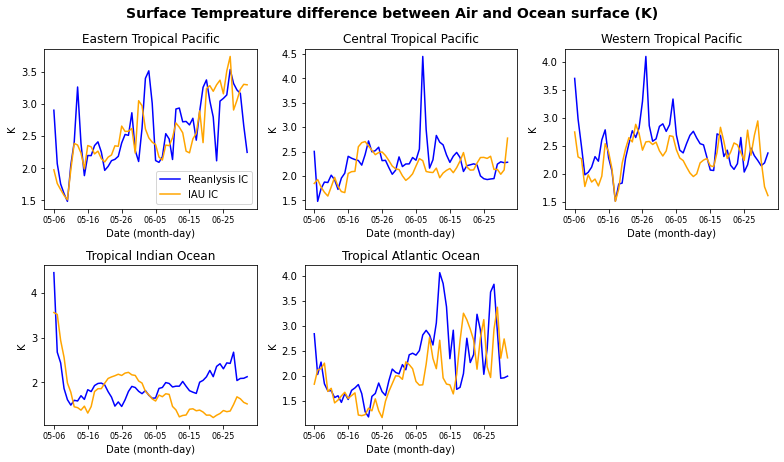

In [73]:

x1=-127
x2=-127
y1=7
y2=7

# x1=-116
# x2=-115
# y1=5
# y2=5

plt.figure(figsize=(11,6.5))
plt.subplot(2,3,1)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Eastern Tropical Pacific')
plt.xticks(arange(len(ticks))[::10],ticks[::10],fontsize=8);
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('K')


x1=-178
x2=-178
y1=2
y2=2

plt.subplot(2,3,2)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Central Tropical Pacific')
plt.xticks(arange(len(ticks))[::10],ticks[::10],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('K')

# x1=136
# x2=137
# y1=3
# y2=4

x1=143
x2=143
y1=-1
y2=-1

plt.subplot(2,3,3)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Western Tropical Pacific')
plt.xticks(arange(len(ticks))[::10],ticks[::10],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('K')

x1=89
x2=92
y1=7
y2=8



plt.subplot(2,3,4)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Indian Ocean')
plt.xticks(arange(len(ticks))[::10],ticks[::10],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('K')

x1=-39
x2=-38
y1=7
y2=8



plt.subplot(2,3,5)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::10],ticks[::10],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('K')

x1=90
x2=91
y1=23
y2=25

# plt.subplot(2,3,6)
# # plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# # plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

# plt.plot((ME506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# #plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

# plt.plot((RP506).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
# #plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
# plt.title('Indian Monsoon')
# plt.xticks(arange(len(ticks))[::10],ticks[::10],fontsize=8);
# plt.xlabel('Date (month-day)')
# plt.ylabel('K')

# x1=32
# x2=35
# y1=-1
# y2=2

plt.suptitle('Surface Tempreature difference between Air and Ocean surface (K)', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('/nobackupp27/afahad/scripts/initialization_shock/spike_delTS.png',dpi=150)

In [9]:
cd /nobackupp27/afahad/exp/GEOSMIT44_cntrl/plot

/nobackupp27/afahad/exp/GEOSMIT44_cntrl/plot


In [10]:
pdir='../plots_CLIM/ocean_mit/'
vdir='/nobackupp11/afahad/mit_diag/'
exp=(os.popen("grep 'setenv  EXPID' ../gcm_run.j").read()[16:-1])
exp=exp.strip()

input_dir = '/nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02'
input_file = 'bathy_eccollc_90x50_min2pts.bin'


In [11]:

try:
	os.system('mkdir -p '+pdir)
except:
	None

bathy = ecco.read_llc_to_tiles(input_dir, input_file)

#ecco.plot_tiles(bathy, layout='latlon',rotate_to_latlon=True,show_tile_labels=False, show_colorbar=True);


ecco_grid = ecco.load_ecco_grid_nc(input_dir, 'ECCO-GRID.nc')


expdir='../mit_output/'
#expdir='/nobackupp11/afahad/exp/GEOSMIT33_rep/scratch/mitocean_run/'
restarts='../restarts/'
start_date=sorted(glob(restarts+'restarts*'))[0][-16:-8]

#cap_restart=open('/nobackupp11/afahad/exp/GEOSMIT39_Rep/scratch/cap_restart', 'r')
#start_date=cap_restart.read()[:8]
exp=os.popen("grep 'setenv  EXPID' ../gcm_run.j").read()[16:-1]

os.chdir(expdir)
files=np.array(sorted(glob('state_2d_set1*.data'))[0:2630])
time=pd.date_range(start_date,periods=len(files),freq='D')

load_binary_array: loading file /nobackupp27/afahad/GEOSMITgcmFiles/mit_input_llc90_02/bathy_eccollc_90x50_min2pts.bin
load_binary_array: data array shape  (1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4


In [12]:
df = pd.DataFrame({'dates': time})

# Filter for specific months (e.g., January and March)
specific_months = [5]  # January and March
filtered_dates = df[df['dates'].dt.month.isin(specific_months)]

In [13]:
files=files[filtered_dates.index]

In [14]:
nt=len(time); nz=1; nf=8; ni=90; nj=90; ntile=13;

ndjf=len(files)

theta_djf=np.zeros((ndjf,nz,ntile,nj,ni)); theta_djf[:]=np.nan

for i in range(ndjf):
	print(files[i])
	data=ecco.read_llc_to_tiles(expdir, files[i], nk=-1,nl=-1)
	data=np.reshape(data, (nf,nz,ntile,nj,ni))
	theta_djf[i,:,:,:]=data[6,:,:,:,:]


state_2d_set1.0000116988.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000116988.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000117180.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000117180.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000117372.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000117372.data
load

load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000121596.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000121596.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000121788.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000121788.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_bin

load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000189372.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000189372.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000189564.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000189564.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_bin

load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000258108.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000258108.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000258300.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000258300.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_face

load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000262524.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000262524.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000262716.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000262716.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_bin

...

llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000403068.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000403068.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000403260.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000403260.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.

load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000471228.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000471228.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000471420.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000471420.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_bin

load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000539964.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000539964.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000540156.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000540156.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_bin

load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000609468.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000609468.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000609660.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000609660.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_bin

load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000613500.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000613500.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_binary_array: data array type  >f4
llc_compact_to_faces: dims, llc  (8, 1170, 90) 90
llc_compact_to_faces: data_compact array type  >f4
llc_faces_to_tiles: data_tiles shape  (8, 13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  >f4
state_2d_set1.0000613692.data
load_binary_array: loading file ../mit_output/state_2d_set1.0000613692.data
load_binary_array: loading all 2D records.  nk = 8
load_binary_array: data array shape  (8, 1170, 90)
load_bin

In [15]:
etan=nanmean(theta_djf,0)

In [16]:
new_grid_delta_lat = 1
new_grid_delta_lon = 1

new_grid_min_lat = -90
new_grid_max_lat = 91

new_grid_min_lon = -180
new_grid_max_lon = 180

new_lat=np.arange(-90,91,1); nlat=len(new_lat)
new_lon=np.arange(-180,180,1); nlon=len(new_lon)
etan=np.squeeze(etan)

tt=len(etan)
etani=np.zeros((nlat,nlon))

for i in range(1):
    for j in range(1):
    
        new_grid_lon_centers, new_grid_lat_centers,\
        new_grid_lon_edges, new_grid_lat_edges,\
        etani[:,:] =\
                ecco.resample_to_latlon(ecco_grid.XC, \
                                        ecco_grid.YC, \
                                        etan[:,:,:],\
                                        new_grid_min_lat, new_grid_max_lat, new_grid_delta_lat,\
                                        new_grid_min_lon, new_grid_max_lon, new_grid_delta_lon,\
                                        fill_value = np.NaN, \
                                        mapping_method = 'nearest_neighbor',
                                        radius_of_influence = 120000)



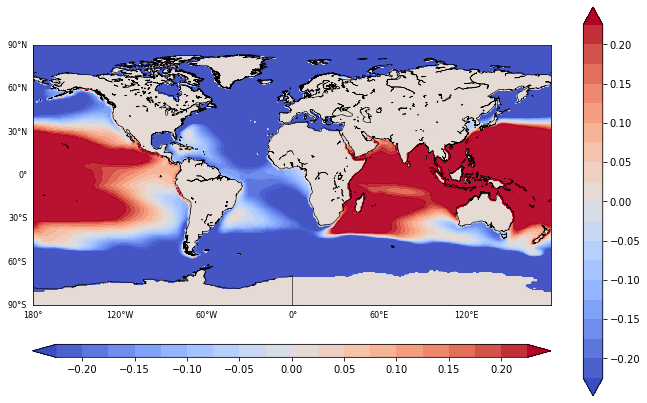

In [17]:
f()
plot(etani,new_lon,new_lat,clf=arange(-.225,.2251,.025),cmap='coolwarm')
plt.colorbar()

In [18]:
ME506.shape

(64, 181, 360)

In [19]:
ME506a=ME506-etani
RP506a=RP506-etani

In [20]:
ME506a.coords["lon"] = ((ME506a.coords["lon"] + 360) % 360)
ME506a=ME506a.sortby("lon")

RP506a.coords["lon"] = ((RP506a.coords["lon"] + 360) % 360)
RP506a=RP506a.sortby("lon")

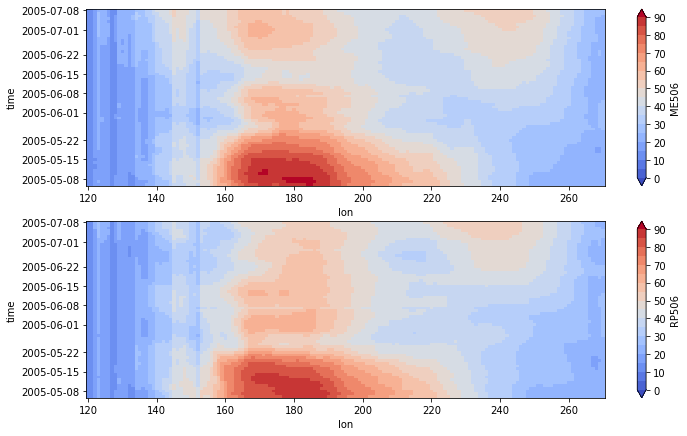

In [21]:
clf=arange(0,91,5)
f()
plt.subplot(2,1,1)
ME506a.sel(lat=slice(-5,5),lon=slice(120,270)).mean(dim='lat').plot(cmap='coolwarm',levels=clf,extend='both')

plt.subplot(2,1,2)
RP506a.sel(lat=slice(-5,5),lon=slice(120,270)).mean(dim='lat').plot(cmap='coolwarm',levels=clf,extend='both')

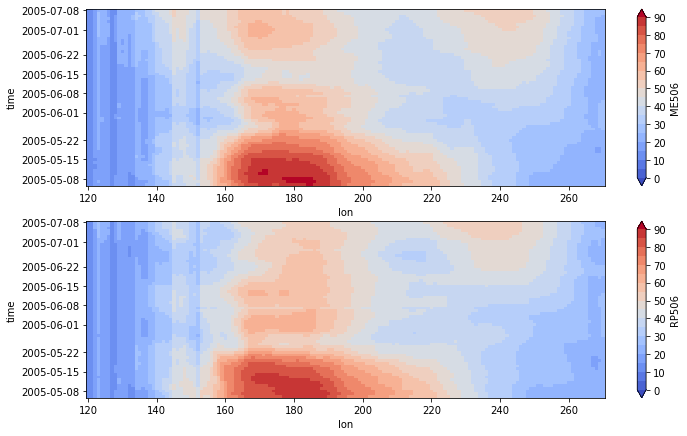

In [22]:
clf=arange(0,91,5)
f()
plt.subplot(2,1,1)
ME506a.sel(lat=slice(-5,5),lon=slice(120,270)).mean(dim='lat').plot(cmap='coolwarm',levels=clf,extend='both')

plt.subplot(2,1,2)
RP506a.sel(lat=slice(-5,5),lon=slice(120,270)).mean(dim='lat').plot(cmap='coolwarm',levels=clf,extend='both')

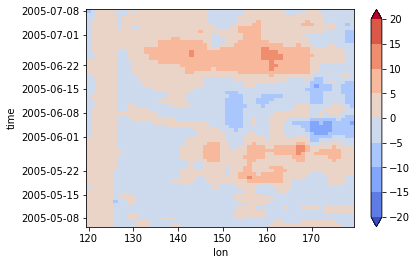

In [27]:
(ME506-RP506).sel(lat=slice(7,7),lon=slice(120,290)).mean(dim='lat').plot(cmap='coolwarm',levels=arange(-20,21,5),extend='both')

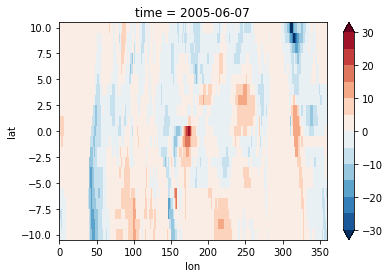

In [25]:
(ME506a-RP506a)[:,:,:].sel(lat=slice(-10,10),time='2005-06-07').plot(levels=arange(-30,31,5),extend='both')